In [1]:
from util import *
plt.rcParams['font.family'] = 'Noto Sans'

%reload_ext autoreload
%autoreload 2

In [2]:
figPath = "../plots/control_designs/"

dirs = [a for a in getDirs(os.path.join(dataPath, 'control'), sstr='nVDCC') if "ISI_20" in a]
dirs.sort(key=natural_keys)
designs = np.array(dirs)

# Get a list of designs in each category 
designs_in_categories = get_designs_in_categories(designs)

for i,d in enumerate(designs): print(i, d)

0 nVDCC_1_dVAZ_60_nAZ_33_RRP_55_ISI_20_nAP_10
1 nVDCC_1_dVAZ_60_nAZ_33_RRP_60_ISI_20_nAP_10
2 nVDCC_2_dVAZ_60_nAZ_7_RRP_60_ISI_20_nAP_10
3 nVDCC_2_dVAZ_60_nAZ_9_RRP_55_ISI_20_nAP_10
4 nVDCC_2_dVAZ_60_nAZ_9_RRP_60_ISI_20_nAP_10
5 nVDCC_2_dVAZ_60_nAZ_11_RRP_40_ISI_20_nAP_10
6 nVDCC_2_dVAZ_60_nAZ_11_RRP_45_ISI_20_nAP_10
7 nVDCC_2_dVAZ_60_nAZ_11_RRP_50_ISI_20_nAP_10
8 nVDCC_2_dVAZ_60_nAZ_13_RRP_35_ISI_20_nAP_10
9 nVDCC_2_dVAZ_60_nAZ_13_RRP_40_ISI_20_nAP_10
10 nVDCC_2_dVAZ_60_nAZ_13_RRP_45_ISI_20_nAP_10
11 nVDCC_2_dVAZ_60_nAZ_13_RRP_50_ISI_20_nAP_10
12 nVDCC_2_dVAZ_60_nAZ_15_RRP_30_ISI_20_nAP_10
13 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
14 nVDCC_2_dVAZ_60_nAZ_17_RRP_30_ISI_20_nAP_10
15 nVDCC_2_dVAZ_60_nAZ_19_RRP_30_ISI_20_nAP_10
16 nVDCC_2_dVAZ_60_nAZ_21_RRP_20_ISI_20_nAP_10
17 nVDCC_2_dVAZ_60_nAZ_21_RRP_25_ISI_20_nAP_10
18 nVDCC_2_dVAZ_60_nAZ_23_RRP_20_ISI_20_nAP_10
19 nVDCC_2_dVAZ_60_nAZ_23_RRP_25_ISI_20_nAP_10
20 nVDCC_2_dVAZ_60_nAZ_25_RRP_20_ISI_20_nAP_10
21 nVDCC_2_dVAZ_60_nAZ_27_

### Load category info
Create category_info.pk file if it doesn't exist. Update it if needed

In [3]:
## If True, recreate category_info.pk. Override if category_info exists.
override = False

category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path) and not override:
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)
        
else:
    # get info (Pr, nRel, MVU, facilitation, Ca peak, residual Ca, syt) of each category
    category_info = np.empty([3,3,3,3], dtype=object)
    for nv, dv, naz, rrp in tq(list(product(range(3), repeat=4))):
        category_info[nv, dv, naz, rrp] = {'n_designs': len(designs_in_categories[nv, dv, naz, rrp])}

        # get representative designs (max and median facilitation)
        category_info[nv, dv, naz, rrp].update(get_rep_design(designs_in_categories[nv, dv, naz, rrp]))

        # Info related to vesicle release
        category_info[nv, dv, naz, rrp].update(get_release_info(designs_in_categories[nv, dv, naz, rrp]))

        # Calcium info
        category_info[nv, dv, naz, rrp].update(get_calcium_info(designs_in_categories[nv, dv, naz, rrp]))

        # Info about synaptotagmin
        category_info[nv, dv, naz, rrp].update(get_synaptotagmin_info(designs_in_categories[nv, dv, naz, rrp]))

        # Info about calcium overlap
        category_info[nv, dv, naz, rrp].update(get_ca_overlap_info(designs_in_categories[nv, dv, naz, rrp]))

    with open(category_info_path, "wb") as infile:
        pk.dump(category_info, infile)
    
    print(category_info[0,0,0,0].keys(), '\n\n', category_info[0,0,0,0])

## If True, update category_info.pk with new design info
update = False
if update:
    for nv, dv, naz, rrp in tq(list(product(range(3), repeat=4))):
        if len(designs_in_categories[nv, dv, naz, rrp]) >= 4:
            # Info about synaptotagmin
            category_info[nv, dv, naz, rrp].update(get_ca_overlap_info(designs_in_categories[nv, dv, naz, rrp]))

    with open(category_info_path, "wb") as infile:
        pk.dump(category_info, infile)

    print(category_info[0,0,0,0]['avg_peak_overlap'])
    print(category_info[2,2,2,1]['avg_basal_overlap'])

In [37]:
for k in list(category_info[0,0,0,0]): print(k)

n_designs
rep_design_max
rep_design_median
pr
rel
mvu
facil
avg_ca_peak
avg_res_ca
avg_ca_syt7_peak
avg_ca_syt1_peak
rep_design_min
avg_peak_overlap
avg_basal_overlap


### Calcium overlap

In [6]:
keys = ['avg_peak_overlap', 'avg_basal_overlap']

y_data = {}
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        design = category_info[nv, dv, naz, rrp]['rep_design_median']
    except KeyError as e:
        # print(f'Could not find design for {cdiv[nv]}, {cdiv[dv]}, {cdiv[naz]}, {cdiv[rrp]}')
        # print(e)
        continue
            
    data_median = pd.read_csv(os.path.join(dataPath, 'control', design, 'result.dat'),
                              usecols=['Pr', 'Rel'], sep='\t')

    avg_peak_overlap, avg_basal_overlap = get_ca_overlap(design)

    label=f'{cdiv[nv]},  {cdiv[dv]},  {cdiv[naz]},  {cdiv[rrp]}'
    y_data[label] = {
        'avg_peak_overlap': avg_peak_overlap, 
        'avg_basal_overlap': avg_basal_overlap,
        'facil': data_median['Rel']*data_median['Pr'][0]/data_median['Pr']/data_median['Rel'][0]
    }
    # break #####################
y_sorted = [list(y['facil']) for y in y_data.values()]
y_sorted.sort(key = lambda x: x[-1], reverse=True)
# print(y_sorted)

des_sorted = []
for yy in y_sorted:
    des_sorted.append([k for k, v in y_data.items() if list(v['facil']) == yy][0])

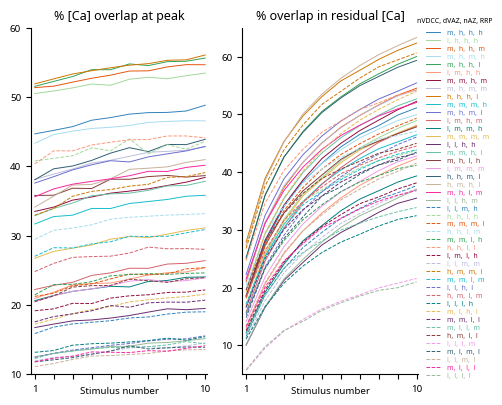

In [13]:
title_text = {'avg_peak_overlap': '% [Ca] overlap at peak',
              'avg_basal_overlap': '% overlap in residual [Ca]'}

marker = ['-','--']
n_plots = len(keys)
fig, ax = plt.subplots(1,n_plots, sharex=True, figsize=(2.5*n_plots,4.5))

for i, key in enumerate(keys):
    y_sorted = [list(y_data[des][key]) for des in des_sorted]

    x = list(range(1,11))
    for j,y in enumerate(y_sorted):
        # print(y)
        # label = [k for k, v in y_data.items() if list(v) == list(y)][0]

        ax[i].plot(x, np.array(y)*100, label=des_sorted[j],
                   # marker='.', markersize=4,
                   linestyle=marker[j//22],
                   linewidth=0.7, color=cpall[j%22])

    ax[i].set_xlim(0.8,10.1)
    ax[i].set_xlabel('Stimulus number', labelpad=-5, fontsize=7)
    ax[i].spines[['right', 'top']].set_visible(False)

    ax[i].set_title(title_text[key], fontsize=9)
    # ax[i].set_xticks([1,4,7,10], [1,4,7,10], fontsize=10)
    ax[i].set_xticks(range(1,11), [1]+['']*8+[10], fontsize=7)
    ax[i].tick_params(axis='y', labelsize=7)
    
ax[-1].legend(frameon=False, loc='center left', bbox_to_anchor=(1.01, 0.49), 
              fontsize=5, handletextpad=1, handlelength=2, 
              labelspacing=0.14, labelcolor='linecolor')

ax[-1].text(10, 66, 'nVDCC, dVAZ, nAZ, RRP', size=5, color=cpdark[-1])
ax[0].set_ylim(10,60)
ax[1].set_ylim(5,65)

plt.show()
fig.savefig(os.path.join(figPath, 'rep_overlap_lineplot.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

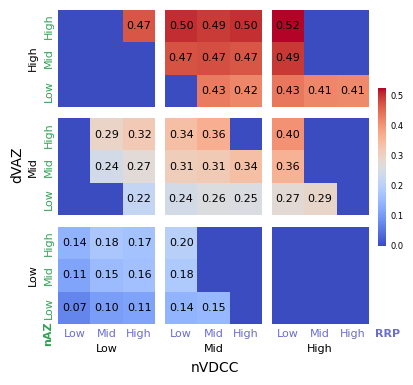

In [53]:
key = 'avg_peak_overlap'
fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5,4.1))
fig.subplots_adjust(wspace=0.1, hspace=0.1)

cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

cases = ['Low', 'Mid', 'High']

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=8)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=8,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=8,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=8)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=8)
       
    ax[nv][dv].spines["bottom"].set_visible(False)
    ax[nv][dv].spines["top"].set_visible(False)
    ax[nv][dv].spines["right"].set_visible(False)
    ax[nv][dv].spines["left"].set_visible(False)
    
ax[-1,0].text(-0.96, -1.12, 'nAZ', size=8, rotation=90, 
              color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.9, 'RRP', size=8, color=cpdark[5], fontweight='bold')
ax[-1,1].text(0.3, -2.0, 'nVDCC', size=10, color=cpdark[-1])
ax[1,0].text(-2, 0.6, 'dVAZ', size=10, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.5, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=0, labelsize=6)

plt.show()
fig.savefig(os.path.join(figPath, f'{key}_4D.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

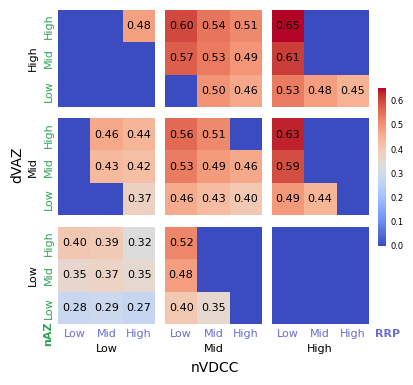

In [54]:
key = 'avg_basal_overlap'
fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5,4.1))
fig.subplots_adjust(wspace=0.1, hspace=0.1)

cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

cases = ['Low', 'Mid', 'High']

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=8)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=8,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=8,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=8)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=8)
       
    ax[nv][dv].spines["bottom"].set_visible(False)
    ax[nv][dv].spines["top"].set_visible(False)
    ax[nv][dv].spines["right"].set_visible(False)
    ax[nv][dv].spines["left"].set_visible(False)
    
ax[-1,0].text(-0.96, -1.12, 'nAZ', size=8, rotation=90, 
              color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.9, 'RRP', size=8, color=cpdark[5], fontweight='bold')
ax[-1,1].text(0.3, -2.0, 'nVDCC', size=10, color=cpdark[-1])
ax[1,0].text(-2, 0.6, 'dVAZ', size=10, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.5, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=0, labelsize=6)

plt.show()
fig.savefig(os.path.join(figPath, f'{key}_4D.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

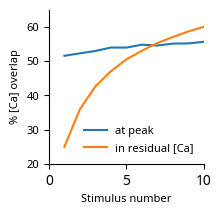

In [30]:
design = 'nVDCC_9_dVAZ_220_nAZ_31_RRP_15_ISI_20_nAP_10'
 
data_median = pd.read_csv(os.path.join(dataPath, 'control', design, 'result.dat'),
                            usecols=['Pr', 'Rel'], sep='\t')

avg_peak_overlap, avg_basal_overlap = get_ca_overlap(design)

y_data = {
    'avg_peak_overlap': avg_peak_overlap, 
    'avg_basal_overlap': avg_basal_overlap
}

keys = ['avg_peak_overlap', 'avg_basal_overlap']

title_text = {'avg_peak_overlap': 'at peak',
              'avg_basal_overlap': 'in residual [Ca]'}

fig, ax = plt.subplots(1, sharex=True, figsize=(2,2))

for i, key in enumerate(keys):
    x = list(range(1,11))
    y = y_data[key]
    ax.plot(x, np.array(y)*100, label=title_text[key])#, color=cpall[j%22])

ax.set_xlim(0.8,10.1)
ax.set_xlabel('Stimulus number', fontsize=8)
ax.set_ylabel('% [Ca] overlap', fontsize=8)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)
    
ax.legend(frameon=False, fontsize=8)
ax.set_xlim(0,10)
ax.set_ylim(20,65)

plt.show()
fig.savefig(os.path.join("../plots/mechanism/", 'ca_overlap.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)